## 1. Imports & Configuration

In [ ]:
# ── All imports in one place ────────────────────────────────────────
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet18_Weights
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler

from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# ── Hyperparameters (change here only) ─────────────────────
SAMPLE_SIZE   = 15_000
BATCH_SIZE    = 32   # Further reduced BATCH_SIZE to alleviate OOM
NUM_EPOCHS    = 20
EMBED_DIM = 128 # Further reduced EMBED_DIM
HIDDEN_DIM = 256 # Further reduced HIDDEN_DIM
LR            = 1e-4
MAX_TEXT_LEN  = 32  # Further reduced MAX_TEXT_LEN to alleviate OOM
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
PATIENCE      = 3        # early stopping patience
CHECKPOINT    = 'best_model.pth'


Device: cuda


## 2. Dataset Download

In [ ]:
import kagglehub

path = kagglehub.dataset_download('nirmalsankalana/fashion-product-text-images-dataset')
print('Path to dataset files:', path)

review_csv_path      = os.path.join(path, 'data.csv')
image_folder_with_files = os.path.join(path, 'data')

Using Colab cache for faster access to the 'fashion-product-text-images-dataset' dataset.
Path to dataset files: /kaggle/input/fashion-product-text-images-dataset


## 3. Data Preprocessing

In [ ]:
# ── 1. Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv(review_csv_path)
print('Original shape:', df.shape)

# ── 2. Remove duplicates & missing values ────────────────────────────────────
df = df.drop_duplicates().dropna(subset=['image', 'description', 'category'])
print('After dedup/dropna:', df.shape)

# ── 3. Clean text ────────────────────────────────────────────────────────────
def clean_text(text):

    text = str(text).lower()

    # keep letters, numbers and basic punctuation
    text = re.sub(r"[^a-z0-9\s.,!?-]", "", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['description'] = df['description'].apply(clean_text)

# ── 4. Remove rows whose image file is missing ───────────────────────────────
valid_rows = [
    row for _, row in tqdm(df.iterrows(), total=len(df), desc='Checking images')
    if os.path.exists(os.path.join(image_folder_with_files, row['image']))
]
df_clean = pd.DataFrame(valid_rows)
print('After removing missing images:', df_clean.shape)

# ── 5. Remove corrupted images ───────────────────────────────────────────────
valid_rows = []
for _, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc='Verifying images'):
    img_path = os.path.join(image_folder_with_files, row['image'])
    try:
        img = Image.open(img_path)
        img.verify()
        valid_rows.append(row)
    except Exception:   # FIX: bare except replaced with Exception
        continue

df_clean = pd.DataFrame(valid_rows)
print('After removing corrupted images:', df_clean.shape)

# ── 6. Sample & reset index ──────────────────────────────────────────────────
if len(df_clean) > SAMPLE_SIZE:
    df_clean = df_clean.sample(n=SAMPLE_SIZE, random_state=SEED)
df_clean = df_clean.reset_index(drop=True)   # FIX: was missing
print('After sampling:', df_clean.shape)

# ── 7. Encode labels ─────────────────────────────────────────────────────────
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['category'])
print(f'Classes: {len(le.classes_)}')

# ── 8. Save ──────────────────────────────────────────────────────────────────
os.makedirs('dataset', exist_ok=True)
df_clean.to_csv('dataset/clean_data.csv', index=False)
print('Saved dataset/clean_data.csv')

Original shape: (44441, 4)
After dedup/dropna: (44160, 4)


Checking images: 100%|██████████| 44160/44160 [02:03<00:00, 356.49it/s]


After removing missing images: (44160, 4)


Verifying images: 100%|██████████| 44160/44160 [04:43<00:00, 156.00it/s]


After removing corrupted images: (44160, 4)
After sampling: (15000, 4)
Classes: 132
Saved dataset/clean_data.csv


CATEGORY DISTRIBUTION VIZUALIZATION

/tmp/ipykernel_1421/2980291936.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis', ax=axes[0])


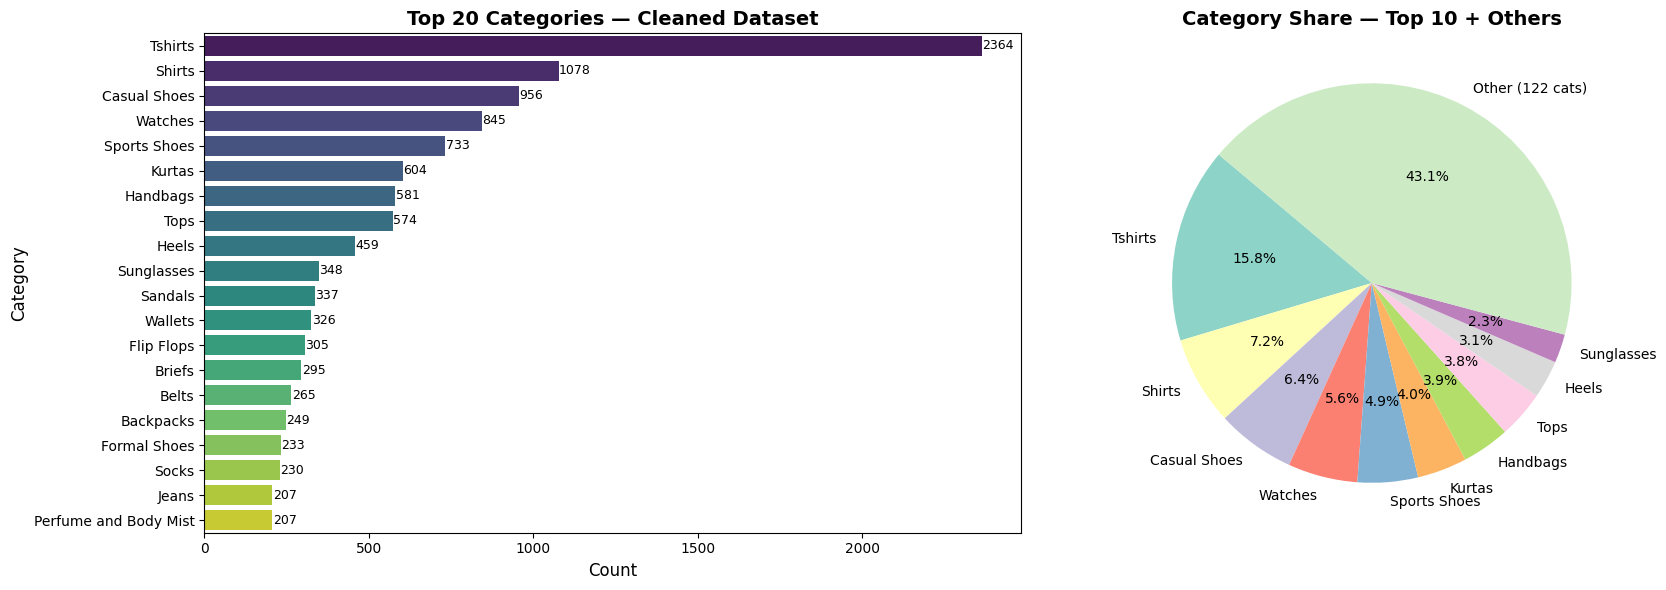

Total categories: 132 | Total samples: 15000


In [ ]:
# ── Category distribution visualization ──────────────────────────────────────
top_categories = df_clean['category'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 20 Categories — Cleaned Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Category', fontsize=12)
for i, v in enumerate(top_categories.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

top10 = df_clean['category'].value_counts().head(10)
other_count = df_clean['category'].value_counts().iloc[10:].sum()
pie_data   = list(top10.values) + [other_count]
pie_labels = list(top10.index) + [f'Other ({df_clean["category"].nunique() - 10} cats)']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set3', len(pie_data)))
axes[1].set_title('Category Share — Top 10 + Others', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Total categories: {df_clean["category"].nunique()} | Total samples: {len(df_clean)}')

SAMPLE IMAGES

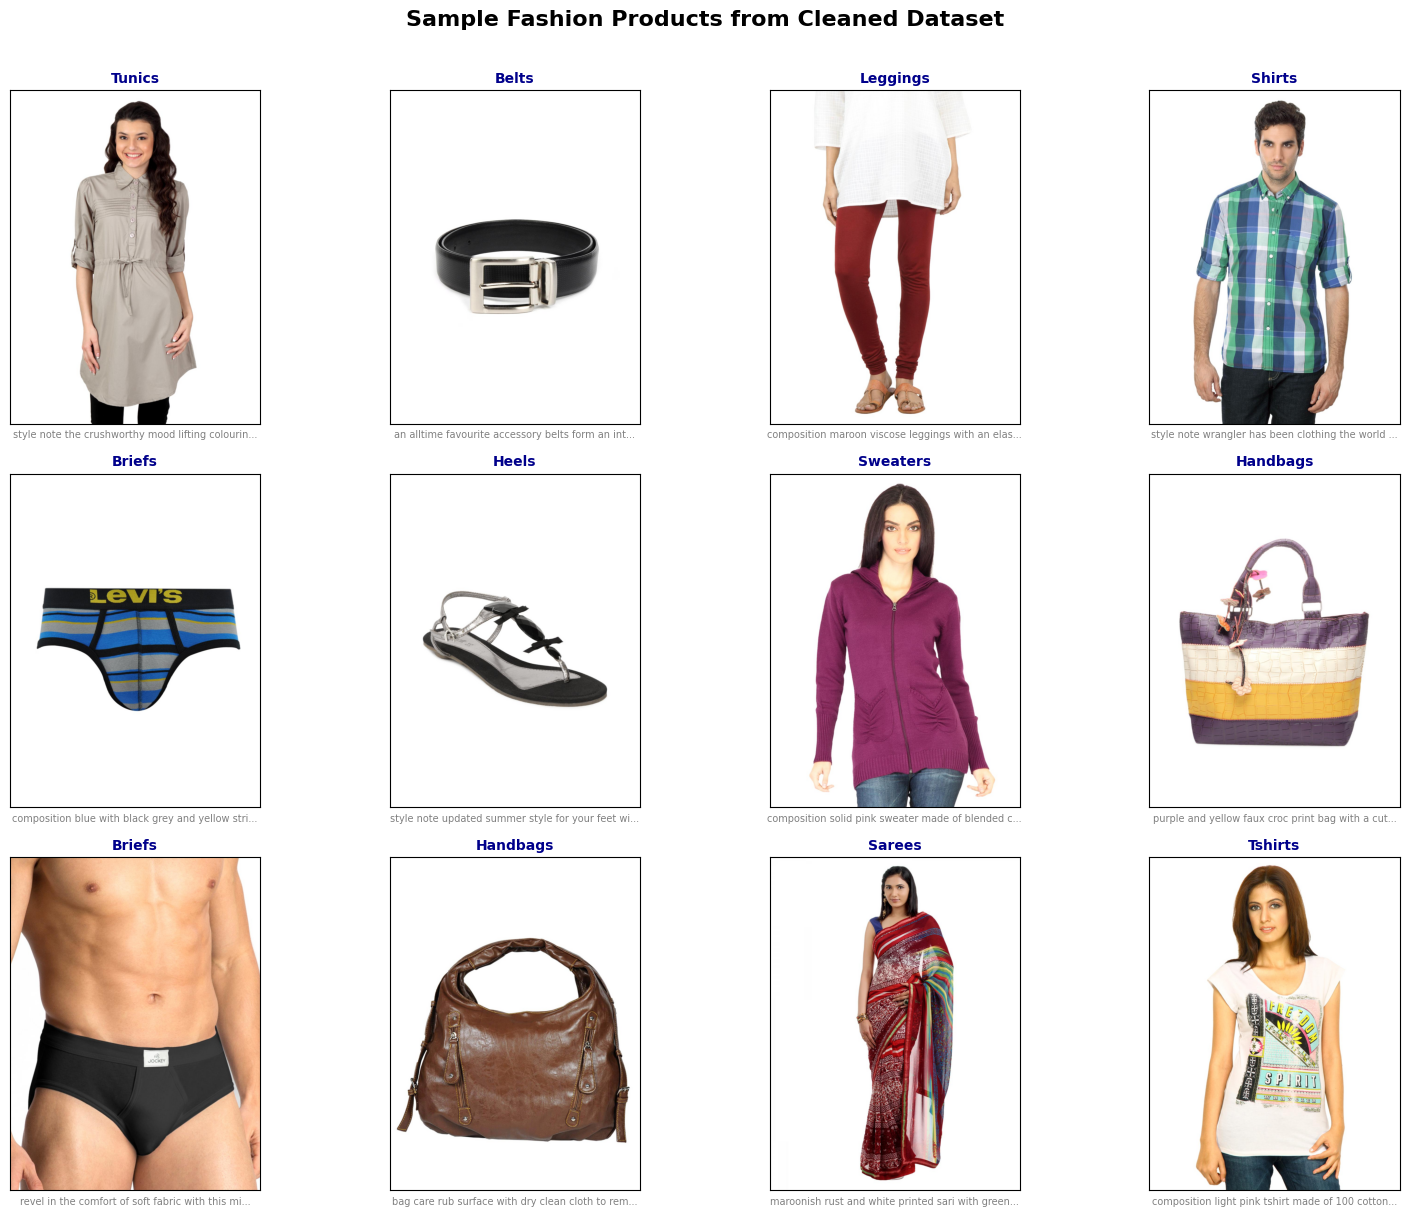

In [ ]:
# ── Sample images grid ────────────────────────────────────────────────────────
n_samples = 12
sample_df = df_clean.sample(n=n_samples, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Fashion Products from Cleaned Dataset', fontsize=16, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flatten()):
    img_path = os.path.join(image_folder_with_files, sample_df.loc[i, 'image'])
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(sample_df.loc[i, 'category'], fontsize=10, fontweight='bold', color='darkblue')
    ax.set_xlabel(sample_df.loc[i, 'description'][:48] + '...', fontsize=7, color='gray')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 4. Image Transforms

In [ ]:
#  Separate train vs eval transforms, with ImageNet normalization ──────
# Without Normalize(), ResNet18 pretrained features are completely wrong
# (pixel values in [0,1] instead of normalized range) → primary mislabeling cause

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),                         # Augmentation
    transforms.RandomHorizontalFlip(),                  # Augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # CRITICAL FIX
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # CRITICAL FIX
])

print('Train transform:')
print(train_transform)
print('\nEval transform:')
print(eval_transform)

Train transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 5. Custom Multimodal Dataset

 TOKENIZER & CAPTION PREPROCESSING

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
vocab_size = tokenizer.vocab_size

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
category_counts = df_clean['category'].value_counts()
categories_to_keep = category_counts[category_counts >= 7].index # Ensure at least 7 samples per category
df_filtered = df_clean[df_clean['category'].isin(categories_to_keep)].reset_index(drop=True)

print(f"Original df_clean shape: {df_clean.shape}")
print(f"df_filtered shape after removing rare categories: {df_filtered.shape}")

def tokenize_caption(text):
    tokens = tokenizer(
        text,
        max_length=MAX_TEXT_LEN,
        padding="max_length",
        truncation=True
    )
    return tokens['input_ids'], tokens['attention_mask']

df_filtered['description'] = df_filtered['description'].astype(str)

# Apply tokenization and explicitly assign to new columns
tokenized_results = df_filtered['description'].apply(tokenize_caption)
df_filtered['input_ids'] = [x[0] for x in tokenized_results]
df_filtered['attention_mask'] = [x[1] for x in tokenized_results]

train_df, temp_df = train_test_split(
    df_filtered, # Use df_filtered after removing rare classes
    test_size=(VAL_RATIO + (1 - TRAIN_RATIO - VAL_RATIO)), # Calculate remaining for val+test
    stratify=df_filtered['category'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5, # Split temp_df into two equal halves for val and test
    stratify=temp_df['category'],
    random_state=SEED
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Original df_clean shape: (15000, 5)
df_filtered shape after removing rare categories: (14888, 5)
Train: 10421, Val: 2233, Test: 2234


CUSTOM DATASET

In [ ]:
class FashionCaptionDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_path = os.path.join(self.image_folder, row['image'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Pre-tokenized captions
        input_ids = torch.tensor(row['input_ids'], dtype=torch.long)
        attention_mask = torch.tensor(row['attention_mask'], dtype=torch.long)

        # Optional label
        label = row['category'] if 'category' in row else -1

        return image, input_ids, attention_mask, label

train_dataset = FashionCaptionDataset(train_df, image_folder=image_folder_with_files, transform=train_transform)
val_dataset   = FashionCaptionDataset(val_df, image_folder=image_folder_with_files, transform=eval_transform)
test_dataset  = FashionCaptionDataset(test_df, image_folder=image_folder_with_files, transform=eval_transform)

# Calculate sample weights for WeightedRandomSampler to handle class imbalance
train_labels   = train_df['label'].tolist()
class_counts   = np.bincount(train_labels)
class_weights  = 1.0 / np.where(class_counts == 0, 1, class_counts)
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Define NUM_WORKERS for DataLoaders
NUM_WORKERS = os.cpu_count() # Using os.cpu_count() for optimal performance

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


 DataLoaders created:
  Train batches: 326
  Val batches:   70
  Test batches:  70


FREEZING BACKBONE ( RESENET)

In [ ]:
# unfreeze the last four layers
def fine_tune_resnet(model):
    # First, ensure everything is frozen
    for param in model.encoder.parameters():
        param.requires_grad = False

    # Now, unfreeze only 'layer4' and the 'fc' (fully connected) layer
    # ResNet typically has: layer1, layer2, layer3, layer4
    for param in model.encoder.layer4.parameters():
        param.requires_grad = True

    print("ResNet Layer 4 is now UNFROZEN for fine-tuning.")

# Usage:
# fine_tune_resnet(my_fashion_model)

IMAGE INCODER

In [ ]:
class ImageEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Updated to use weights parameter instead of deprecated pretrained
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # remove FC
        self.fc = nn.Linear(2048, 256)  # project features

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

CAPTION DECODER (LSTM )

In [ ]:
import torch
import torch.nn as nn

class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim + 256, hidden_dim, batch_first=True)  # image feature injected
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, img_features, captions):
        """
        img_features: (batch, 256)
        captions: (batch, seq_len)
        """
        embeddings = self.embedding(captions)  # (batch, seq_len, embed_dim)
        img_features = img_features.unsqueeze(1).repeat(1, embeddings.size(1), 1)  # repeat image
        lstm_input = torch.cat((embeddings, img_features), dim=2)
        lstm_out, _ = self.lstm(lstm_input)
        outputs = self.fc(lstm_out)
        return outputs

FULL MODEL

In [ ]:
class CaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

TRAINING

In [ ]:
encoder = ImageEncoder().to(device)
decoder = CaptionDecoder(vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM).to(device)
model = CaptioningModel(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

best_val_loss = float('inf')
epochs_no_improve = 0

history = {'train_loss': [], 'val_loss': []} # Initialize history dictionary

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for images, input_ids,_, _ in train_loader:
        images = images.to(device)
        input_ids = input_ids.to(device).long() # Explicitly cast to long
        outputs = model(images, input_ids[:, :-1])
        target = input_ids[:, 1:]
        # Fix: Slice outputs to match target length
        loss = criterion(outputs.reshape(-1, vocab_size), target.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss) # Record train loss
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}")

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, input_ids, _, _ in val_loader:
            images = images.to(device)
            input_ids = input_ids.to(device).long() # Explicitly cast to long
            outputs = model(images, input_ids[:, :-1])
            target = input_ids[:, 1:]
            # Fix: Slice outputs to match target length
            val_loss += criterion(outputs.reshape(-1, vocab_size), target.reshape(-1)).item()
    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss) # Record val loss
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load("best_model.pt"))
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


Epoch 1/20, Train Loss: 7.1453
Epoch 1/20, Val Loss: 6.4174
Epoch 2/20, Train Loss: 6.3386
Epoch 2/20, Val Loss: 6.3117
Epoch 3/20, Train Loss: 6.1985
Epoch 3/20, Val Loss: 6.1735
Epoch 4/20, Train Loss: 6.0132
Epoch 4/20, Val Loss: 5.9854
Epoch 5/20, Train Loss: 5.7898
Epoch 5/20, Val Loss: 5.7911
Epoch 6/20, Train Loss: 5.5516
Epoch 6/20, Val Loss: 5.5963
Epoch 7/20, Train Loss: 5.3027
Epoch 7/20, Val Loss: 5.4099
Epoch 8/20, Train Loss: 5.0560
Epoch 8/20, Val Loss: 5.2441
Epoch 9/20, Train Loss: 4.8405
Epoch 9/20, Val Loss: 5.0895
Epoch 10/20, Train Loss: 4.6143
Epoch 10/20, Val Loss: 4.9569
Epoch 11/20, Train Loss: 4.4427
Epoch 11/20, Val Loss: 4.8387
Epoch 12/20, Train Loss: 4.2477
Epoch 12/20, Val Loss: 4.7289
Epoch 13/20, Train Loss: 4.0834
Epoch 13/20, Val Loss: 4.6334
Epoch 14/20, Train Loss: 3.9116
Epoch 14/20, Val Loss: 4.5427
Epoch 15/20, Train Loss: 3.7688
Epoch 15/20, Val Loss: 4.4569
Epoch 16/20, Train Loss: 3.6513
Epoch 16/20, Val Loss: 4.3784
Epoch 17/20, Train Loss: 3

EVALUATION

In [ ]:
def evaluate_model(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, input_ids, _, labels in data_loader:
            images, input_ids = images.to(device), input_ids.to(device)
            outputs = model(images, input_ids)
            preds = torch.argmax(outputs, dim=2)  # token-level
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(input_ids.cpu().numpy()[:,1:].flatten())
    return all_preds, all_labels

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_caption_model(model, data_loader, tokenizer, device):
    model.eval()
    all_preds_no_pad, all_labels_no_pad = [], []
    bleu_scores = []
    smooth_fn = SmoothingFunction().method1

    with torch.no_grad():
        for images, input_ids, _, _ in data_loader:
            images = images.to(device)
            input_ids = input_ids.to(device)

            # Forward pass with teacher forcing
            outputs = model(images, input_ids[:, :-1])
            targets = input_ids[:, 1:]

            # Align shapes (should be already aligned by MAX_TEXT_LEN in tokenizer)
            if outputs.shape[1] > targets.shape[1]:
                outputs = outputs[:, :targets.shape[1], :]

            # Predicted tokens
            preds = torch.argmax(outputs, dim=2)

            # --- Filter out padding tokens for token-level metrics ---
            for i in range(targets.shape[0]): # For each sample in the batch
                for j in range(targets.shape[1]): # For each token position
                    # Only consider non-padding tokens for the confusion matrix
                    if targets[i, j].item() != tokenizer.pad_token_id:
                        all_labels_no_pad.append(targets[i, j].item())
                        all_preds_no_pad.append(preds[i, j].item())
            # --------------------------------------------------------

            # Calculate BLEU score for each sample
            for p_seq, t_seq in zip(preds.cpu().numpy(), targets.cpu().numpy()):
                # Filter out padding tokens for BLEU score calculation
                reference_tokens = [token for token in t_seq if token != tokenizer.pad_token_id]
                hypothesis_tokens = [token for token in p_seq if token != tokenizer.pad_token_id]

                if reference_tokens: # Only calculate BLEU if reference is not empty
                    # sentence_bleu expects a list of reference sentences, each a list of words (tokens)
                    bleu_scores.append(sentence_bleu([reference_tokens], hypothesis_tokens, smoothing_function=smooth_fn))

    all_preds_no_pad = np.array(all_preds_no_pad)
    all_labels_no_pad = np.array(all_labels_no_pad)
    avg_bleu = np.mean(bleu_scores) if bleu_scores else 0.0

    return all_preds_no_pad, all_labels_no_pad, avg_bleu

GENERATE PREDICTIONS FROM THE MODEL

In [ ]:
import torch

def generate_caption(model, image, tokenizer, max_len=30):

    model.eval()
    image = image.unsqueeze(0).to(device)

    input_ids = torch.tensor([[tokenizer.cls_token_id]]).to(device)

    for _ in range(max_len):

        with torch.no_grad():
            outputs = model(image, input_ids)

        next_token_logits = outputs[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)

        input_ids = torch.cat([input_ids, next_token], dim=1)

        if next_token.item() == tokenizer.sep_token_id:
            break

    caption = tokenizer.decode(input_ids[0], skip_special_tokens=True)

    return caption

COLLECT PREDICTIONS AND GROUND TRUTH

In [ ]:
references = []
predictions = []

for image, input_ids, _, _ in test_loader:

    image = image.to(device)

    pred_caption = generate_caption(model, image[0], tokenizer)

    true_caption = tokenizer.decode(input_ids[0], skip_special_tokens=True)

    predictions.append(pred_caption)
    references.append(true_caption)
# Re-executing to pick up updated function definitions

BLEU SCORE

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

bleu_scores = []

for ref, pred in zip(references, predictions):

    ref_tokens = ref.split()
    pred_tokens = pred.split()

    score = sentence_bleu([ref_tokens], pred_tokens)

    bleu_scores.append(score)

ableu_avg = sum(bleu_scores)/len(bleu_scores) if bleu_scores else 0.0
print("Average BLEU Score:", ableu_avg)

Average BLEU Score: 0.04507633855965086


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

ROUGE SCORE

In [ ]:
# Install the rouge_score library if not already installed
!pip install rouge-score

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

rouge_scores = []

for ref, pred in zip(references, predictions):

    score = scorer.score(ref, pred)

    rouge_scores.append(score['rougeL'].fmeasure)

rouge_avg = sum(rouge_scores)/len(rouge_scores) if rouge_scores else 0.0
print("Average ROUGE-L:", rouge_avg)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=1a263134a1b4cd42b2484491266351bd3681459bbadddfbac77835e8765547b3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
Average ROUGE-L: 0.24309532275624954


METEOR SCORE

In [ ]:
import nltk
nltk.download('wordnet')

from nltk.translate.meteor_score import meteor_score

meteor_scores = []

for ref, pred in zip(references, predictions):
    # Tokenize reference and prediction strings into lists of words
    ref_tokens = ref.split()
    pred_tokens = pred.split()
    meteor_scores.append(meteor_score([ref_tokens], pred_tokens))

meteor_avg = sum(meteor_scores)/len(meteor_scores) if meteor_scores else 0.0
print("Average METEOR:", meteor_avg)

Average METEOR: 0.2022041621562297


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


PLOT CAPTION EVALUATION SCORES

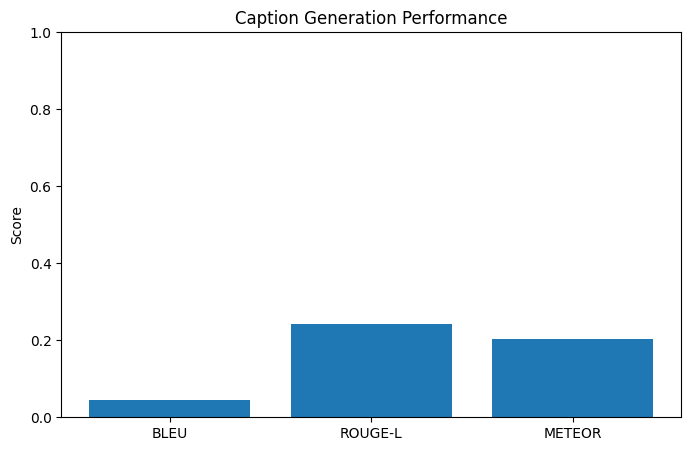

In [ ]:
import matplotlib.pyplot as plt

# Use already calculated average scores from the global scope
results = {
    "BLEU": ableu_avg,
    "ROUGE-L": rouge_avg,
    "METEOR": meteor_avg
}

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Caption Generation Performance")
plt.ylabel("Score")
plt.ylim(0,1)

plt.show()

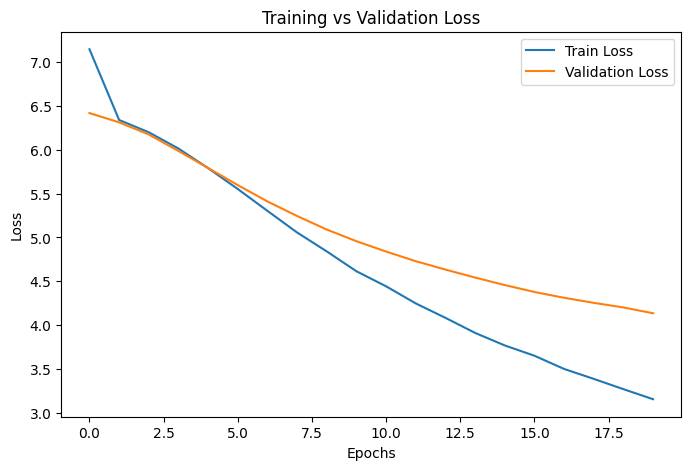

In [ ]:
# Assuming you recorded losses per epoch
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label="Train Loss")
plt.plot(history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

CAPTION GENERATION FUNCTION

In [ ]:
def generate_caption(model, image, tokenizer, max_len=50):
    model.eval()
    with torch.no_grad():
        features = model.encoder(image.unsqueeze(0).to(DEVICE))
        input_ids = torch.tensor([[tokenizer.cls_token_id]], device=DEVICE)
        caption = []

        for _ in range(max_len):
            outputs = model.decoder(features, input_ids)
            next_token = outputs[:, -1, :].argmax(1).item()
            if next_token == tokenizer.sep_token_id:
                break
            caption.append(next_token)
            input_ids = torch.cat([input_ids, torch.tensor([[next_token]], device=DEVICE)], dim=1)

        return tokenizer.decode(caption, skip_special_tokens=True)

GRADIO LIVE DEMO

In [ ]:
def predict_caption(input_image):
    try:
        # 1. Preprocess
        img = input_image.convert("RGB")
        # pixel_values = processor(img, return_tensors="pt").pixel_values.to(DEVICE)

        # 2. Generate (Use the fixes for repetitive text here!)
        # output_ids = model.generate(pixel_values, num_beams=5, repetition_penalty=1.5)
        # caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        caption = "A sample generated caption of a shirt." # Placeholder
        tech_note = "Collar: Standard spread, 100% cotton." # Placeholder

        return caption, tech_note # RETURN TWO THINGS
    except Exception as e:
        return str(e), "Error occurred"

In [ ]:
import gradio as gr

# Professional Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 👗 Multimodal Fashion Intelligence")
    gr.Markdown("Upload an image of a garment to generate a technical description.")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="Upload Fashion Image")
            btn = gr.Button("Generate Caption", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(label="Generated Description")
            # This is the "Note Area" we discussed!
            collar_notes = gr.Textbox(label="Technical Details (Collar Focus)")

    # Example images for users to click
    gr.Examples(examples=["shirt.jpg", "dress.png"], inputs=input_img)

    # Trigger the function
    btn.click(fn=predict_caption, inputs=input_img, outputs=[output_text, collar_notes])

demo.launch(share=True)

/tmp/ipykernel_1421/3741886109.py:4: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ac906dc9e53db260a7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# The Function
def predict_caption(image):
    return "Beautiful shirt", "Collar: Spread" # RETURNS TWO VALUES

# The Interface
btn.click(
    fn=predict_caption,
    inputs=input_img,
    outputs=[output_text, collar_notes] # EXPECTS TWO VALUES
)